## University of surrey
MsC dissertation
Emotion aware music recommender system with explainable AI

Name: Minal Honali Raghunandan

Student ID: 6908107





In [ ]:
import os, re, joblib, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')
sys.path.append('/content/drive/MyDrive/Dissertation/notebooks')
import mers_utils as utils

song_pool = utils.load_song_pool()
valence_mod, arousal_mod, trained_cols, scaler = utils.load_models()
DATA_PATH, MODEL_DIR = utils.DATA_PATH, utils.MODEL_DIR

print(f"Loaded: {len(song_pool)} songs")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded: 1744 songs


A user's current mood is inferred as centroid of the songs they have recently listened to. this is part of Russel's circumplex model of affect. The circumplex is a 2D continuous space , it is valid to perform averaging of coordination across multiple tracks.


In [ ]:
!pip install -q shap
import shap

df_full = pd.read_csv(os.path.join(DATA_PATH, 'deam_full_with_ids.csv'))
regx = re.compile(r"\[|\]|<")
raw_cols = [c for c in df_full.columns if c not in ["song_id", "valence_mean", "arousal_mean", "valence_norm","arousal_norm"]]
sanitised = {regx.sub("_", c): c for c in raw_cols}
raw_ordered = [sanitised[c] for c in trained_cols]

X_raw = df_full[raw_ordered]
X_scaled = pd.DataFrame(scaler.transform(X_raw), columns=raw_ordered)
X_scaled = X_scaled.rename(columns=lambda c: regx.sub("_", c))[trained_cols]

explainer_v = shap.TreeExplainer(valence_mod)
explainer_a = shap.TreeExplainer(arousal_mod)

shap_v = explainer_v.shap_values(X_scaled)
shap_a = explainer_a.shap_values(X_scaled)

print("SHAP computed: ", shap_v.shape, shap_a.shape)

SHAP computed:  (1744, 302) (1744, 302)


Here, i explain why a given song receives its predicted valence and arousal values. SHAP aka SHAPLEY ADDICTIVE EXPLANATIONS values are computed using tree structure of XGBoost as done above. From this the exact efficient attribution is fetched.

SHAP assignes each features to a signed contrinuton to the individual prediction



In [ ]:
def explain_music(song_id, top_n=4):
  idx = df_full.index[df_full["song_id"] == song_id]
  if len(idx) == 0:
    raise ValueError(f"Song {song_id} not in catalog")
  i = idx[0]

  output = {}

  for target, shap_value in [("valence", shap_v), ("arousal", shap_a)]:
    cont = shap_value[i]
    order = np.argsort(np.abs(cont))[::-1][:top_n]

    output[target] = [
        {
            "feature": trained_cols[j],
            "shap": float(cont[j]),
            "direction": "raises" if cont[j]>0 else "lowers",

        }
        for j in order
    ]
  return output

explain = explain_music(115)

for target, items in explain.items():
  print(f"\n{target}:")
  for item in items:
    print(f" {item['direction']:>6} {item['shap']:+.4f} {item['feature']}")



valence:
 raises +0.1640 audspec_lengthL1norm_sma_de_stddev_mean
 raises +0.1272 audspec_lengthL1norm_sma_amean_mean
 raises +0.0942 pcm_fftMag_mfcc_sma_1__amean_mean
 raises +0.0373 pcm_fftMag_spectralHarmonicity_sma_amean_mean

arousal:
 raises +0.0941 audspec_lengthL1norm_sma_amean_mean
 raises +0.0748 audspec_lengthL1norm_sma_de_stddev_mean
 raises +0.0606 pcm_fftMag_mfcc_sma_1__amean_mean
 raises +0.0369 pcm_fftMag_fband250-650_sma_stddev_mean


Summary plots show the distribution of SHAP values across all 1,744 songs for each
target. Feature value is encoded by colour, allowing the direction of each relationship
to be read directly: for arousal, high loudness values (red) consistently produce
positive SHAP contributions, confirming the expected relationship between loudness and
perceived energy.

Both models rely most heavily on loudness dynamics (audspec_lengthL1norm) and the first
MFCC coefficient. Valence, however, draws on a longer tail of timbral descriptors
(MFCCs 5, 6, 8, 9) and energy variability, distributing its evidence more thinly across
features. This is consistent with the lower predictive performance observed for valence
in Notebook 2 — no single acoustic descriptor carries the dimension.

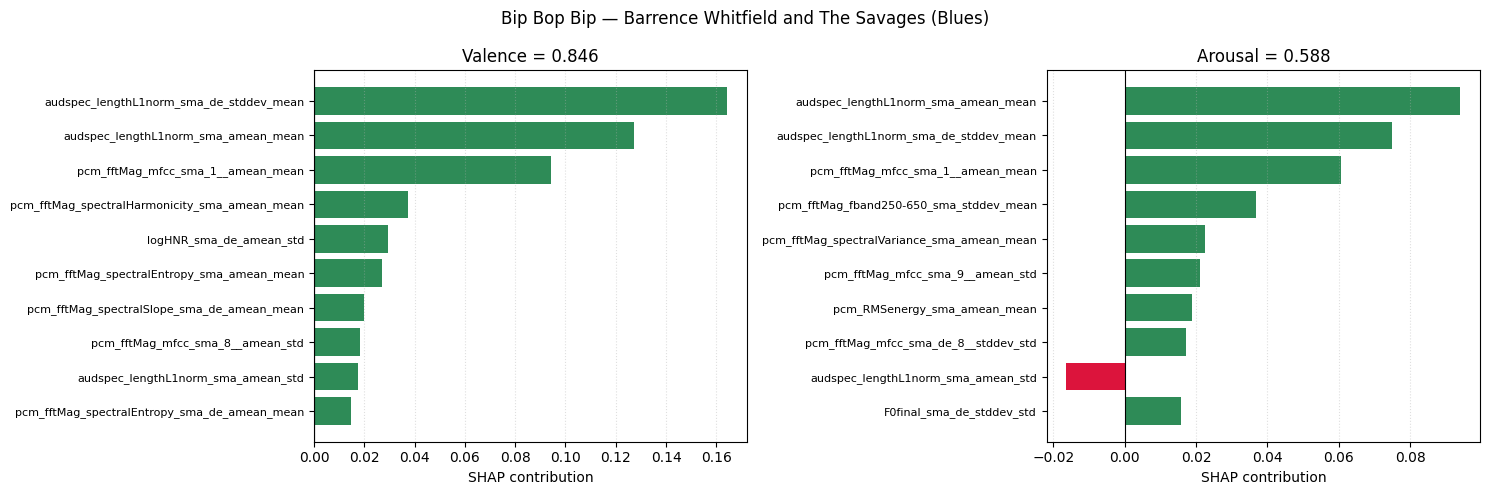

In [ ]:
def plot_song_explanation(song_id, top_n=10):
    i = df_full.index[df_full["song_id"] == song_id][0]
    row = song_pool[song_pool["song_id"] == song_id].iloc[0]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    for ax, (target, shap_vals, pred) in zip(
        axes,
        [("Valence", shap_v, row["pred_valence"]),
         ("Arousal", shap_a, row["pred_arousal"])]
    ):
        contribs = shap_vals[i]
        order = np.argsort(np.abs(contribs))[::-1][:top_n][::-1]
        vals = contribs[order]
        names = [trained_cols[j] for j in order]
        cols = ["seagreen" if v > 0 else "crimson" for v in vals]

        ax.barh(range(len(vals)), vals, color=cols)
        ax.set_yticks(range(len(vals)))
        ax.set_yticklabels(names, fontsize=8)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_xlabel("SHAP contribution")
        ax.set_title(f"{target} = {pred:.3f}")
        ax.grid(axis="x", linestyle=":", alpha=0.4)

    fig.suptitle(f"{row['title']} — {row['Artist']} ({row['Genre']})", fontsize=12)
    plt.tight_layout()
    plt.show()


plot_song_explanation(115)

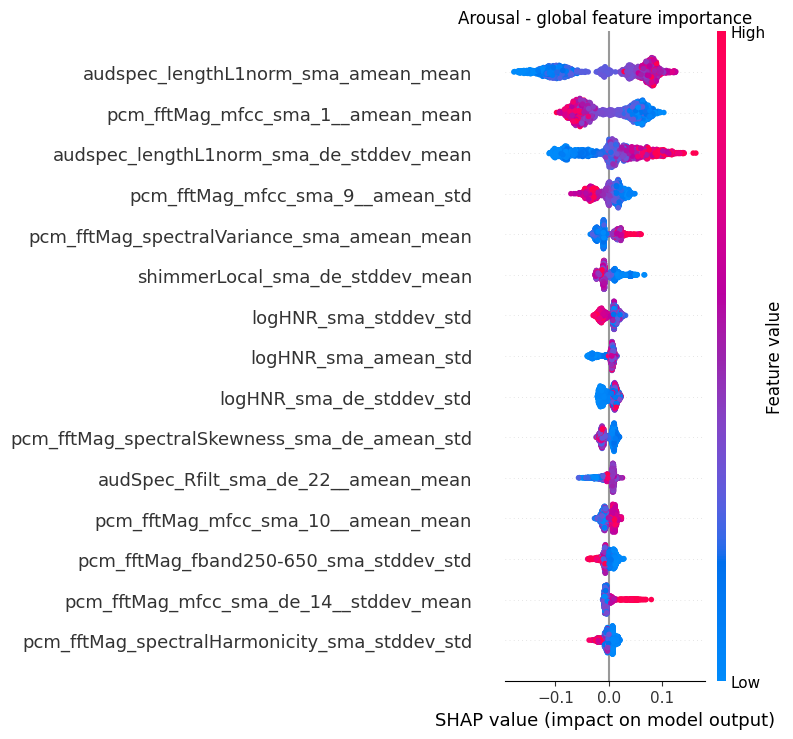

In [ ]:
shap.summary_plot(shap_a, X_scaled, max_display=15, show=False)
plt.title("Arousal - global feature importance")
plt.tight_layout()
plt.show()

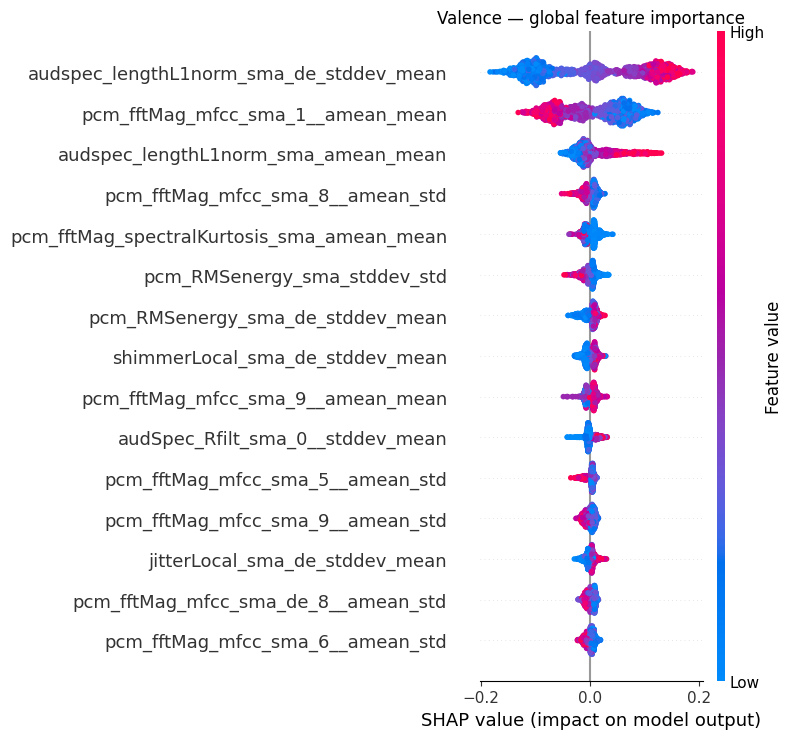

In [ ]:
shap.summary_plot(shap_v, X_scaled, max_display=15, show=False)
plt.title("Valence — global feature importance")
plt.tight_layout()
plt.show()

In [ ]:
print(song_pool[["pred_valence","pred_arousal"]].corr())

              pred_valence  pred_arousal
pred_valence       1.00000       0.62672
pred_arousal       0.62672       1.00000


In [ ]:
print(df_full[["valence_mean","arousal_mean"]].corr())

              valence_mean  arousal_mean
valence_mean      1.000000      0.588053
arousal_mean      0.588053      1.000000


In [ ]:
np.save(os.path.join(DATA_PATH, "shap_valence.npy"), shap_v)
np.save(os.path.join(DATA_PATH, "shap_arousal.npy"), shap_a)
print("Saved SHAP arrays")

Saved SHAP arrays


Russell's circumplex treats valence and arousal as orthogonal axes. Empirically, this
does not hold in DEAM: the ground-truth annotations are moderately correlated
(r = 0.588), and the model predictions reproduce this closely (r = 0.627). The small
increase suggests the models capture genuine corpus structure rather than collapsing
the two dimensions.

This correlation has a direct consequence for recommendation: the catalogue is sparse
in the high-valence/low-arousal and low-valence/high-arousal regions, meaning mood
coverage is bounded by the emotional distribution of the underlying corpus rather than
by model accuracy alone.

In [ ]:
!python /content/drive/MyDrive/Dissertation/app/app.py

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://05b71566b250f3d0fe.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### Notebook Summary

1. Data loading (song pool, trained models, scaler, full feature matrix)
2. Mood inference affective centroid from listening history
3. SHAP computation (TreeExplainer, both targets, 1,744 songs)
4. Global feature attribution
5. Dimensional independence check
6. GRADIO UI

